# Political markets

### Generate search queries for every market

In [ ]:
import os
import json
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY_1"))

MODEL = "llama-3.3-70b-versatile" # knowledge cutoff in December 2023 (?)

NUM_QUERIES = 5
MAX_WORDS = 8

INPUT_PATH = "data/political_markets/markets.json"
OUTPUT_PATH = "data/political_markets/search_queries.json"

def call_llm(prompt: str) -> str:
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
    )
    return resp.choices[0].message.content


def extract_queries(text: str):
    for line in text.splitlines():
        if "Search Queries" in line:
            part = line.split(":", 1)[-1]
            queries = [q.strip() for q in part.split(";") if q.strip()]
            return queries
    return []


def build_prompt_1(question, resolution_criteria):
    return f"""I will provide you with a forecasting question and the resolution criteria for the question.
Question: {question}
Resolution criteria: {resolution_criteria}
Today's date: {datetime.now().strftime("%Y-%m-%d")}
Task:
- Generate brief search queries (up to {MAX_WORDS} words each) to gather information on Google that could influence the forecast.
You must generate this exact amount of queries: {NUM_QUERIES}
Your response should take the following structure: Thoughts: {{ Insert your thinking here. }}
Search Queries: {{ Insert the queries here. Use semicolons to separate the queries. }}"""


def build_prompt_2(question, resolution_criteria):
    return f"""I will provide you with a forecasting question and the resolution criteria for the question. I will
then ask you to generate short search queries (up to {MAX_WORDS} words each) that I’ll use to find
articles on Google News to help answer the question.
Question: {question}
Resolution criteria: {resolution_criteria}
Today's date: {datetime.now().strftime("%Y-%m-%d")}
You must generate this exact amount of queries: {NUM_QUERIES}
Start off by writing down sub-questions. Then use your sub-questions to help steer the search queries
you produce.
Your response should take the following structure: Thoughts: {{ Insert your thinking here. }}
Search Queries: {{ Insert the queries here. Use semicolons to separate the queries. }}"""


def process_item(item):
    q = item["question"]
    r = item["resolution_criteria"]

    out1 = call_llm(build_prompt_1(q, r))
    out2 = call_llm(build_prompt_2(q, r))

    queries = extract_queries(out1) + extract_queries(out2)

    # deduplicate (case-insensitive)
    seen = set()
    final_queries = []
    for x in queries:
        key = x.lower()
        if key not in seen:
            seen.add(key)
            final_queries.append(x)

    item["search_queries"] = final_queries
    return item

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

enriched = []
for i, item in enumerate(data, start=1):
    print(f"Processing item {i}/{len(data)}: {item.get('question', '')[:60]}...")
    enriched.append(process_item(item))

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(enriched, f, indent=2, ensure_ascii=False)

Processing item 1/3: Will the AfD be the Berlin State Election Winner?...
Processing item 2/3: Strait of Hormuz traffic returns to normal by end of April?...
Processing item 3/3: US x Iran permanent peace deal by May 31?...


### 1) Call NewsAPI.org

In [ ]:
import json
import os
import requests
import time
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("NEWSAPI_ORG_KEY")
INPUT_PATH = "data/political_markets/search_queries.json"
OUTPUT_PATH = "data/political_markets/newsapi_raw_results.json"
BASE_URL = "https://newsapi.org/v2/everything"
TOP_N = 20

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_markets = []

for market in data:
    print(f"\nMarket: {market.get('question')}")

    market_result = {
        "question": market.get("question"),
        "queries": []
    }

    for query in market.get("search_queries", []):
        print(f"  Query: {query}")

        params = {
            "q": query,
            "pageSize": TOP_N,
            "language": "en",
            "sortBy": "publishedAt",
            "apiKey": API_KEY
        }

        r = requests.get(BASE_URL, params=params)
        result = r.json()

        market_result["queries"].append({
            "query": query,
            "response": result
        })

        time.sleep(1)

    all_markets.append(market_result)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(all_markets, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)


Market: Will the AfD be the Berlin State Election Winner?
  Query: AfD Berlin election polls
  Query: Berlin state election schedule
  Query: AfD popularity in Berlin
  Query: Berlin election candidate list
  Query: AfD Berlin election campaign
  Query: Berlin state election predictions
  Query: AfD campaign issues Berlin
  Query: Berlin election AfD chances
  Query: AfD vs other parties Berlin election
  Query: Berlin state election winner

Market: Strait of Hormuz traffic returns to normal by end of April?
  Query: Strait of Hormuz traffic update
  Query: Hormuz shipping lane news
  Query: IMF Portwatch Strait data
  Query: Strait of Hormuz maritime news
  Query: Recent Hormuz ship traffic
  Query: Strait of Hormuz ship traffic update
  Query: IMF Portwatch Strait of Hormuz data
  Query: Normal traffic levels Strait of Hormuz
  Query: Strait of Hormuz news April 2026
  Query: IMF Portwatch transit calls report

Market: US x Iran permanent peace deal by May 31?
  Query: US Iran peace

In [ ]:
import json
import os
import requests
import time
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("NEWSAPI_ORG_KEY")
INPUT_PATH = "data/political_markets/search_queries.json"
OUTPUT_PATH = "data/political_markets/top_headlines_de.json"
BASE_URL = "https://newsapi.org/v2/top-headlines"
TOP_N = 20
COUNTRY = "de"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_markets = []

for market in data:
    print(f"\nMarket: {market.get('question')}")

    market_result = {
        "question": market.get("question"),
        "queries": []
    }

    for query in market.get("search_queries", []):
        print(f"  Query: {query}")

        params = {
            "q": query,
            "pageSize": TOP_N,
            "country": COUNTRY,
            "apiKey": API_KEY
        }

        r = requests.get(BASE_URL, params=params)
        result = r.json()

        market_result["queries"].append({
            "query": query,
            "response": result
        })

        time.sleep(1)

    all_markets.append(market_result)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(all_markets, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)


Market: Will the AfD be the Berlin State Election Winner?
  Query: AfD Berlin election polls
  Query: Berlin state election schedule
  Query: AfD popularity in Berlin
  Query: Berlin election candidate list
  Query: AfD Berlin election campaign
  Query: Berlin state election predictions
  Query: AfD campaign issues Berlin
  Query: Berlin election AfD chances
  Query: AfD vs other parties Berlin election
  Query: Berlin state election winner

Market: Strait of Hormuz traffic returns to normal by end of April?
  Query: Strait of Hormuz traffic update
  Query: Hormuz shipping lane news
  Query: IMF Portwatch Strait data
  Query: Strait of Hormuz maritime news
  Query: Recent Hormuz ship traffic
  Query: Strait of Hormuz ship traffic update
  Query: IMF Portwatch Strait of Hormuz data
  Query: Normal traffic levels Strait of Hormuz
  Query: Strait of Hormuz news April 2026
  Query: IMF Portwatch transit calls report

Market: US x Iran permanent peace deal by May 31?
  Query: US Iran peace

### 1) Scrape articles' full text

In [ ]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup

INPUT_PATH = "data/political_markets/newsapi_raw_results.json"
OUTPUT_PATH = "data/political_markets/articles_newsapi.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}

def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()
        if a.text and len(a.text) > 200:
            return a.text
    except Exception:
        pass
    return None

def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            return None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            return None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        return text if len(text) > 200 else None

    except Exception:
        return None

def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)
        return text if len(text) > 200 else None
    except Exception:
        return None

def get_full_text(url):
    text = extract_newspaper(url)
    if text:
        return text

    text = extract_readability(url)
    if text:
        return text

    return extract_fallback(url)


with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n===== Market {mi}/{len(data)} =====")

    for qi, q in enumerate(market.get("queries", []), start=1):
        query = q.get("query")
        articles = q.get("response", {}).get("articles", [])
        print(f"\nQuery {qi}: {query} ({len(articles)} articles)")
        
        for ai, a in enumerate(articles, start=1):
            url = a.get("url")
            print(f"  [{ai}/{len(articles)}] {url}")
            if not url:
                a["full_text"] = None
                continue
            text = get_full_text(url)
            a["full_text"] = text
            if not text:
                print("   -> scrape failed")
            time.sleep(1.0)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 3

===== Market 1/3 =====

Query 1: AfD Berlin election polls (3 articles)
  [1/3] https://www.huffpost.com/entry/trump-orban-campaign_n_69d8182fe4b0ccb589ebd505
  [2/3] http://foreignpolicy.com/2026/04/02/germany-israel-postwar-consensus/
   -> scrape failed
  [3/3] https://www.irishtimes.com/world/europe/2026/03/30/germany-at-a-crossroads-as-years-of-stagnation-come-to-a-head/

Query 2: Berlin state election schedule (2 articles)
  [1/2] https://github.com/public-apis/public-apis/blob/master/README.md
  [2/2] https://vonng.com/en/pg/extension-504/

Query 3: AfD popularity in Berlin (3 articles)
  [1/3] https://wattsupwiththat.com/2026/04/18/cracks-appear-in-climate-consensus-as-germanys-energy-minister-admits-renewable-energy-is-ruining-the-country/
  [2/3] https://www.dw.com/en/germany-news-people-change-easter-holiday-plans-amid-crises/live-76650036
  [3/3] https://www.politico.eu/article/friedrich-merz-popularity-sinks-new-lows-germany-government-support-collapses/


### 2) Call GNews API

In [ ]:
import json
import os
import requests
import time
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("GNEWS_API_KEY_1")
INPUT_PATH = "data/political_markets/search_queries.json"
OUTPUT_PATH = "data/political_markets/gnews_api_raw_results.json"
BASE_URL = "https://gnews.io/api/v4/search"
TOP_N = 20

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_markets = []

for market in data:
    print(f"\nMarket: {market.get('question')}")

    market_result = {
        "question": market.get("question"),
        "queries": []
    }

    for query in market.get("search_queries", []):
        print(f"  Query: {query}")

        params = {
            "q": query,
            "lang": "en",
            "max": TOP_N,
            "sortby": "publishedAt",
            "apikey": API_KEY
        }

        r = requests.get(BASE_URL, params=params)
        result = r.json()

        if r.status_code != 200:
            print("  API ERROR:", result)

        market_result["queries"].append({
            "query": query,
            "response": result
        })

        time.sleep(1.05)

    all_markets.append(market_result)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(all_markets, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)


Market: Will the AfD be the Berlin State Election Winner?
  Query: AfD Berlin election polls
  Query: Berlin state election schedule
  Query: AfD popularity in Berlin
  Query: Berlin election candidate list
  Query: AfD Berlin election campaign
  Query: Berlin state election predictions
  Query: AfD campaign issues Berlin
  Query: Berlin election AfD chances
  Query: AfD vs other parties Berlin election
  Query: Berlin state election winner

Market: Strait of Hormuz traffic returns to normal by end of April?
  Query: Strait of Hormuz traffic update
  Query: Hormuz shipping lane news
  Query: IMF Portwatch Strait data
  Query: Strait of Hormuz maritime news
  Query: Recent Hormuz ship traffic
  Query: Strait of Hormuz ship traffic update
  Query: IMF Portwatch Strait of Hormuz data
  Query: Normal traffic levels Strait of Hormuz
  Query: Strait of Hormuz news April 2026
  Query: IMF Portwatch transit calls report

Market: US x Iran permanent peace deal by May 31?
  Query: US Iran peace

### 2) Scrape articles' full text

In [ ]:
import json
import time
import requests
from newspaper import Article
from readability import Document
from bs4 import BeautifulSoup

INPUT_PATH = "data/political_markets/gnews_api_raw_results.json"
OUTPUT_PATH = "data/political_markets/articles_gnews_api.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}


def extract_newspaper(url):
    try:
        a = Article(url)
        a.download()
        a.parse()
        if a.text and len(a.text) > 200:
            return a.text
    except Exception:
        pass
    return None


def extract_readability(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)

        if not r.text or len(r.text) < 200:
            return None

        doc = Document(r.text)
        html = doc.summary()

        if not html or len(html) < 200:
            return None

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n")

        return text if len(text) > 200 else None

    except Exception:
        return None


def extract_fallback(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        paragraphs = soup.find_all("p")
        text = "\n".join(p.get_text() for p in paragraphs)
        return text if len(text) > 200 else None
    except Exception:
        return None


def get_full_text(url):
    text = extract_newspaper(url)
    if text:
        return text

    text = extract_readability(url)
    if text:
        return text

    return extract_fallback(url)


# -------------------
# LOAD DATA
# -------------------
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total markets: {len(data)}")

# -------------------
# SCRAPING LOOP
# -------------------
for mi, market in enumerate(data, start=1):
    print(f"\n===== Market {mi}/{len(data)} =====")

    for qi, q in enumerate(market.get("queries", []), start=1):
        query = q.get("query")

        # GNews structure
        articles = q.get("response", {}).get("articles", [])

        print(f"\nQuery {qi}: {query} ({len(articles)} articles)")

        for ai, a in enumerate(articles, start=1):
            url = a.get("url")

            print(f"  [{ai}/{len(articles)}] {url}")

            if not url:
                a["full_text"] = None
                continue

            text = get_full_text(url)
            a["full_text"] = text

            if not text:
                print("   -> scrape failed")

            time.sleep(1.0)


# -------------------
# SAVE
# -------------------
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 3

===== Market 1/3 =====

Query 1: AfD Berlin election polls (0 articles)

Query 2: Berlin state election schedule (0 articles)

Query 3: AfD popularity in Berlin (1 articles)
  [1/1] https://abc17news.com/news/national-world/cnn-world/2026/04/15/remigration-and-russian-lessons-german-far-right-party-promises-radical-measures-if-elected/

Query 4: Berlin election candidate list (0 articles)

Query 5: AfD Berlin election campaign (0 articles)

Query 6: Berlin state election predictions (0 articles)

Query 7: AfD campaign issues Berlin (0 articles)

Query 8: Berlin election AfD chances (0 articles)

Query 9: AfD vs other parties Berlin election (0 articles)

Query 10: Berlin state election winner (0 articles)

===== Market 2/3 =====

Query 1: Strait of Hormuz traffic update (1 articles)
  [1/1] https://www.devdiscourse.com/article/headlines/3880441-update-1-shipping-traffic-remains-at-virtual-standstill-through-hormuz-data-shows

Query 2: Hormuz shipping lane news (1 arti

### 3) Use gnews package

In [ ]:
import json
import time
from gnews import GNews

INPUT_PATH = "data/political_markets/search_queries.json"
OUTPUT_PATH = "data/political_markets/gnews_package_raw_results.json"

TOP_N = 20

gnews = GNews(
    language="en",
    max_results=TOP_N
)

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_markets = []

for market in data:
    print(f"\nMarket: {market.get('question')}")

    market_result = {
        "question": market.get("question"),
        "queries": []
    }

    for query in market.get("search_queries", []):
        print(f"  Query: {query}")

        try:
            articles = gnews.get_news(query)
            result = {
                "status": "ok",
                "totalResults": len(articles),
                "articles": articles
            }

        except Exception as e:
            print("   ERROR:", e)
            result = {
                "status": "error",
                "totalResults": 0,
                "articles": []
            }

        market_result["queries"].append({
            "query": query,
            "response": result
        })

        time.sleep(1)

    all_markets.append(market_result)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(all_markets, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)


Market: Will the AfD be the Berlin State Election Winner?
  Query: AfD Berlin election polls
  Query: Berlin state election schedule
  Query: AfD popularity in Berlin
  Query: Berlin election candidate list
  Query: AfD Berlin election campaign
  Query: Berlin state election predictions
  Query: AfD campaign issues Berlin
  Query: Berlin election AfD chances
  Query: AfD vs other parties Berlin election
  Query: Berlin state election winner

Market: Strait of Hormuz traffic returns to normal by end of April?
  Query: Strait of Hormuz traffic update
  Query: Hormuz shipping lane news
  Query: IMF Portwatch Strait data
  Query: Strait of Hormuz maritime news
  Query: Recent Hormuz ship traffic
  Query: Strait of Hormuz ship traffic update
  Query: IMF Portwatch Strait of Hormuz data
  Query: Normal traffic levels Strait of Hormuz
  Query: Strait of Hormuz news April 2026
  Query: IMF Portwatch transit calls report

Market: US x Iran permanent peace deal by May 31?
  Query: US Iran peace

### 3) Scrape articles' full text

In [ ]:
import json
import time
import requests
from datetime import datetime
from gnews import GNews

INPUT_PATH = "data/political_markets/gnews_package_raw_results.json"
OUTPUT_PATH = "data/political_markets/articles_gnews_package.json"

gnews = GNews()

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"
}

def convert_date(date_str):
    if not date_str:
        return None
    try:
        dt = datetime.strptime(date_str, "%a, %d %b %Y %H:%M:%S GMT")
        return dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    except Exception:
        return None

def get_full_text(url):
    try:
        article = gnews.get_full_article(url)

        if article.text and len(article.text) > 200:
            return article.text
        else:
            print("   -> empty text")

    except Exception as e:
        print(f"   -> error: {type(e).__name__}")

    return None

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total markets: {len(data)}")

for mi, market in enumerate(data, start=1):
    print(f"\n===== Market {mi}/{len(data)} =====")

    for qi, q in enumerate(market.get("queries", []), start=1):
        query = q.get("query")
        articles = q.get("response", {}).get("articles", [])

        print(f"\nQuery {qi}: {query} ({len(articles)} articles)")

        for ai, a in enumerate(articles, start=1):
            url = a.get("url")
            print(f"  [{ai}/{len(articles)}] {url}")

            # fix date
            a["publishedAt"] = convert_date(a.get("published date"))

            # normalize source
            publisher = a.get("publisher")
            if isinstance(publisher, dict):
                a["source"] = {"name": publisher.get("title")}
            else:
                a["source"] = {"name": publisher}

            if not url:
                a["full_text"] = None
                print("   -> no url")
                continue

            text = get_full_text(url)
            a["full_text"] = text

            if not text:
                print("   -> scrape failed")

            time.sleep(1.0)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("\nSaved:", OUTPUT_PATH)

Total markets: 3

===== Market 1/3 =====

Query 1: AfD Berlin election polls (20 articles)
  [1/20] https://news.google.com/rss/articles/CBMilgFBVV95cUxPYXBVQWYxYU44SWstOFoyeEhwa3ZUUFpBclZmSEJpVDkxNjJNdU1sOUN5b3JzUU9jdHctTGk2cEJudHYxUzNzbzdBN1dKa1hNVTlEQkZBNXlRSkF1NEVXdkhMNzFrbUtTdUZId0Uzb2RNLWZuaGVOM0dwSE1jcU1scHh1d1NZVEo4R0MxTFVFbkFZbHd1VGc?oc=5&hl=en-US&gl=US&ceid=US:en
   -> empty text
   -> scrape failed
  [2/20] https://news.google.com/rss/articles/CBMixAFBVV95cUxNYkk0cU50MmplYmdfR0tFVHJlcDFmcGRyTTBuZWlacU41c1JFbDVFZV9id1AwUzhKQ0hLMXkwMWtTTEgwWXJyUXpXeTBnaXk1R25lbnZFUV9vSDdFSnlnV0QxbTJQakRvYWV4MzBUdmdXLXY3Q3dLZDVpOEJmX3ROeXowTEJRZXpjazVyV29xSnpkM1hYRlU1TnRVVS1rWWVHcm1RMnp3bUZ6RE1odVhRTHdOUXhIeEtVUnNxei11Ukp0cG9I?oc=5&hl=en-US&gl=US&ceid=US:en
   -> empty text
   -> scrape failed
  [3/20] https://news.google.com/rss/articles/CBMiywFBVV95cUxQVjFLRW5FYWtRRkI0WkhqbWRhTUx3NmVBaGU1TnlmaDNZWmVmVG12WU1LU3hCenVaVFdKZjFONFdjR0lpRHRfNWNHVGpuc2dsRzNqdms0WC1hRmlJbDZoR2FJTzI2d0pWN000SEhHY0RxNk

### Standardise JSON files

In [ ]:
import json
import glob
import os

os.makedirs("data/political_markets/comparison", exist_ok=True)

for name in glob.glob("data/political_markets/articles_*.json"):
    with open(name) as f:
        data = json.load(f)
    
    output = []
    for question_obj in data:
        new_queries = []
        for qry in question_obj["queries"]:
            articles = []
            for a in qry.get("response", {}).get("articles", []):
                if not a:
                    continue
                articles.append({
                    "title": a.get("title"),
                    "url": a.get("url"),
                    "published_date": a.get("publishedAt") or a.get("published date") or a.get("published_date"),
                    "source": a.get("source", {}).get("name") if isinstance(a.get("source"), dict) else a.get("source"),
                    "full_text": a.get("full_text")
                })
            new_queries.append({
                "query": qry["query"],
                "articles": articles
            })
        output.append({
            "question": question_obj["question"],
            "queries": new_queries
        })
    
    # Extract just the filename from the full path
    base_name = os.path.basename(name)
    new_name = base_name.replace(".json", "_standard.json")
    out_path = os.path.join("data/political_markets/comparison", new_name)
    
    with open(out_path, "w") as f:
        json.dump(output, f, indent=2)

### Inspect articles ("everything" endpoint)

Found 3 file(s) to process



=== articles_gnews_api ===
Total articles: 92
Missing full text: 2 (2.17%)
Earliest article: 02 April 2026
Latest article:   28 April 2026


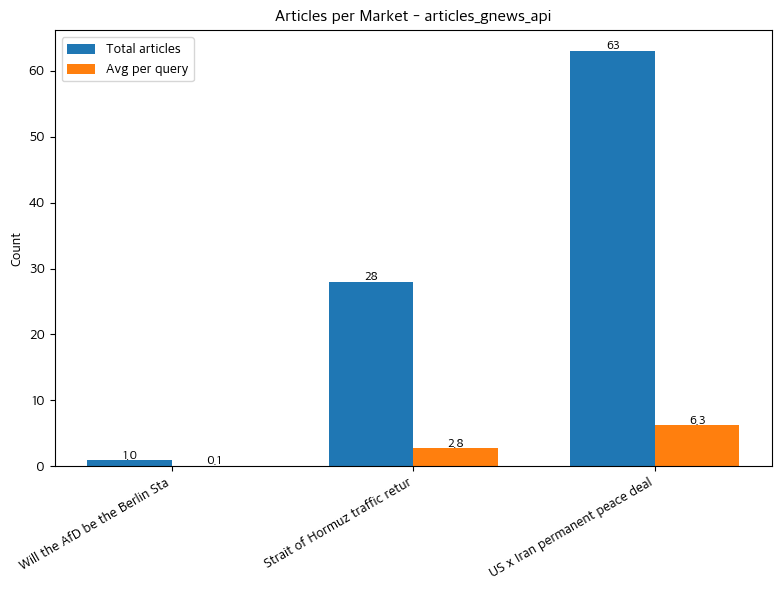

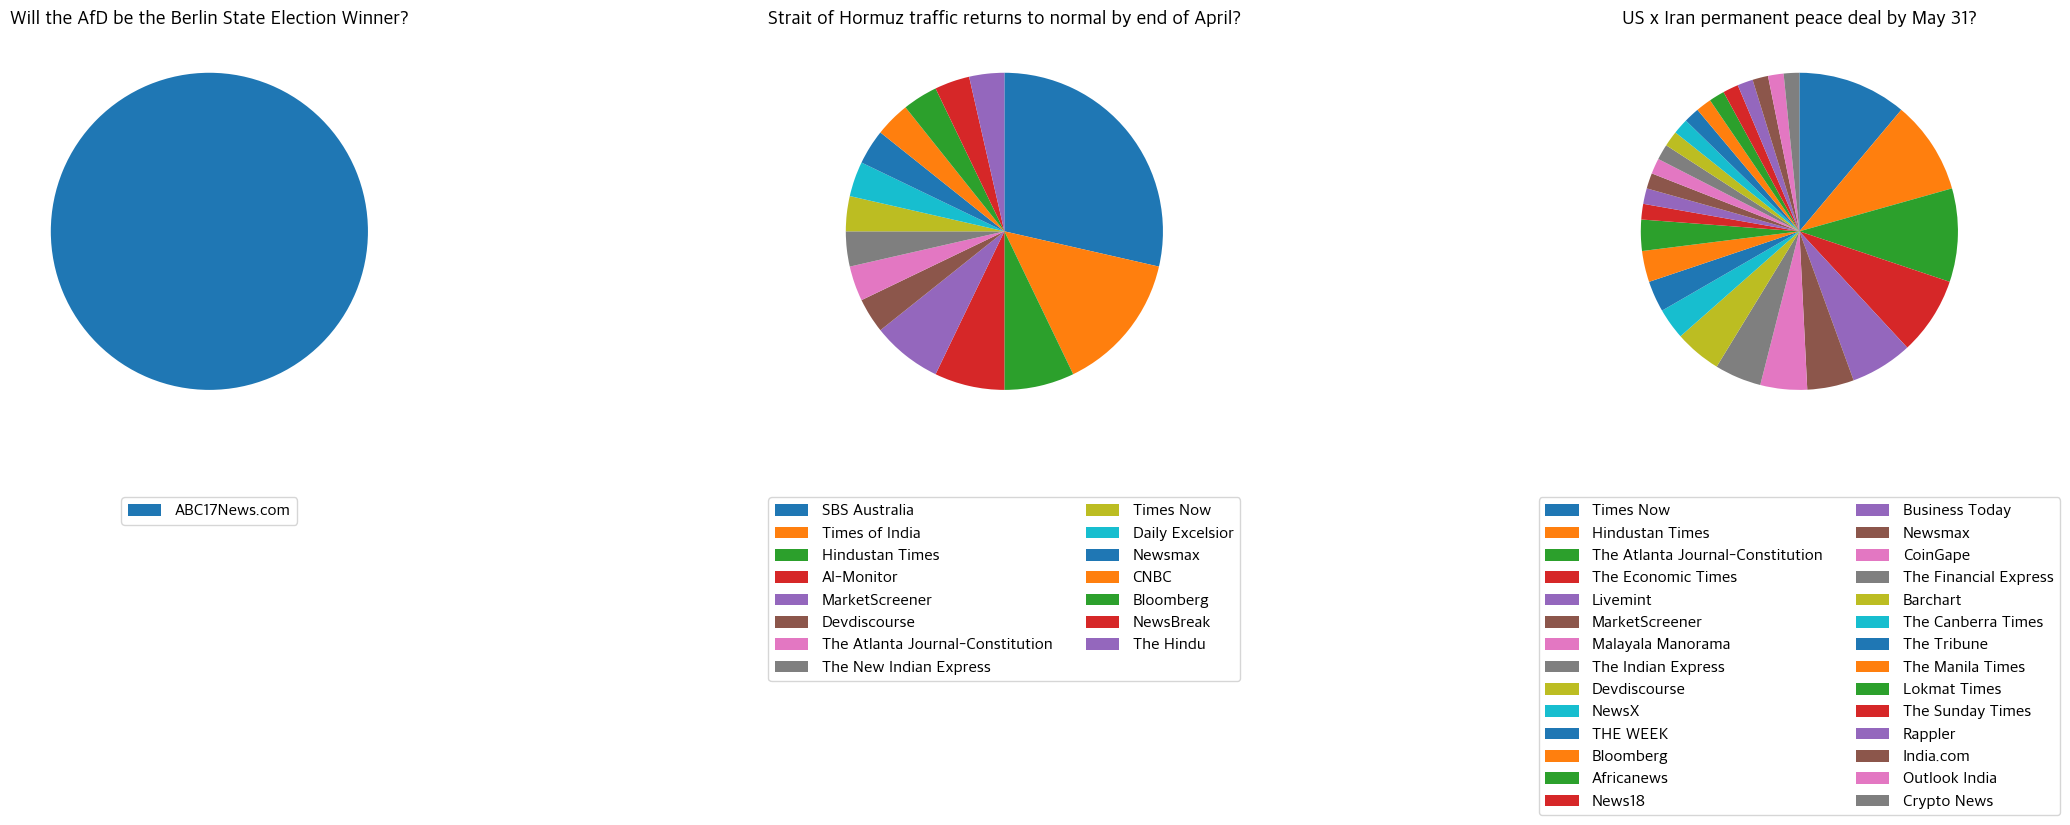



=== articles_gnews_package ===
Total articles: 583
Missing full text: 583 (100.00%)
Earliest article: 30 September 2020
Latest article:   05 May 2026


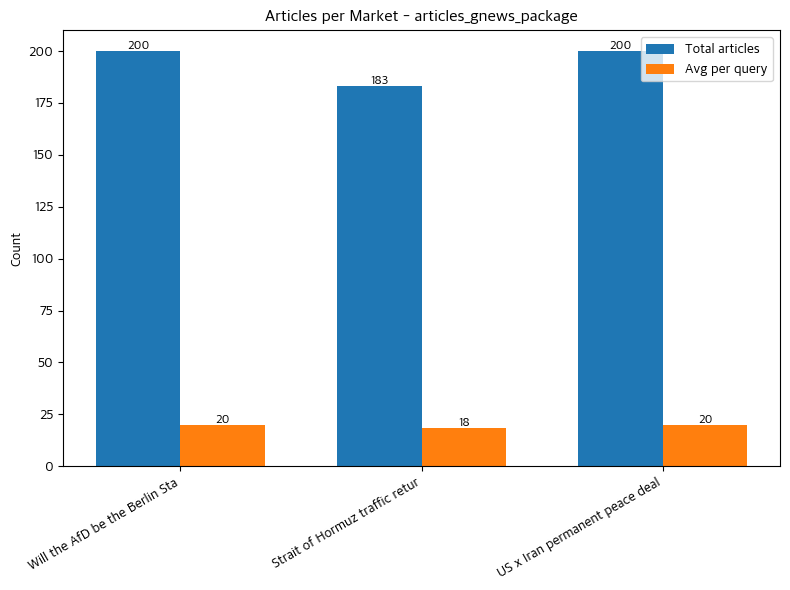

/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8r0000gr/T/ipykernel_69973/1648469556.py:159: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from font(s) Apple SD Gothic Neo.
  plt.tight_layout()
/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8r0000gr/T/ipykernel_69973/1648469556.py:159: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8r0000gr/T/ipykernel_69973/1648469556.py:159: UserWarning: Glyph 1740 (\N{ARABIC LETTER FARSI YEH}) missing from font(s) Apple SD Gothic Neo.
  plt.tight_layout()
/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8r0000gr/T/ipykernel_69973/1648469556.py:159: UserWarning: Glyph 1585 (\N{ARABIC LETTER REH}) missing from font(s) Apple SD Gothic Neo.
  plt.tight_layout()
/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8r0000gr/T/ipykernel_69973/1648469556.py:159: UserWarning: Glyph 1606 (\N{ARABIC LETTER NOON}) missing from font(s) Apple SD Gothic Neo.
  plt.tight_layout()
/var/folders/l1/swc02p9s1f1fsnsjzgsd8d8

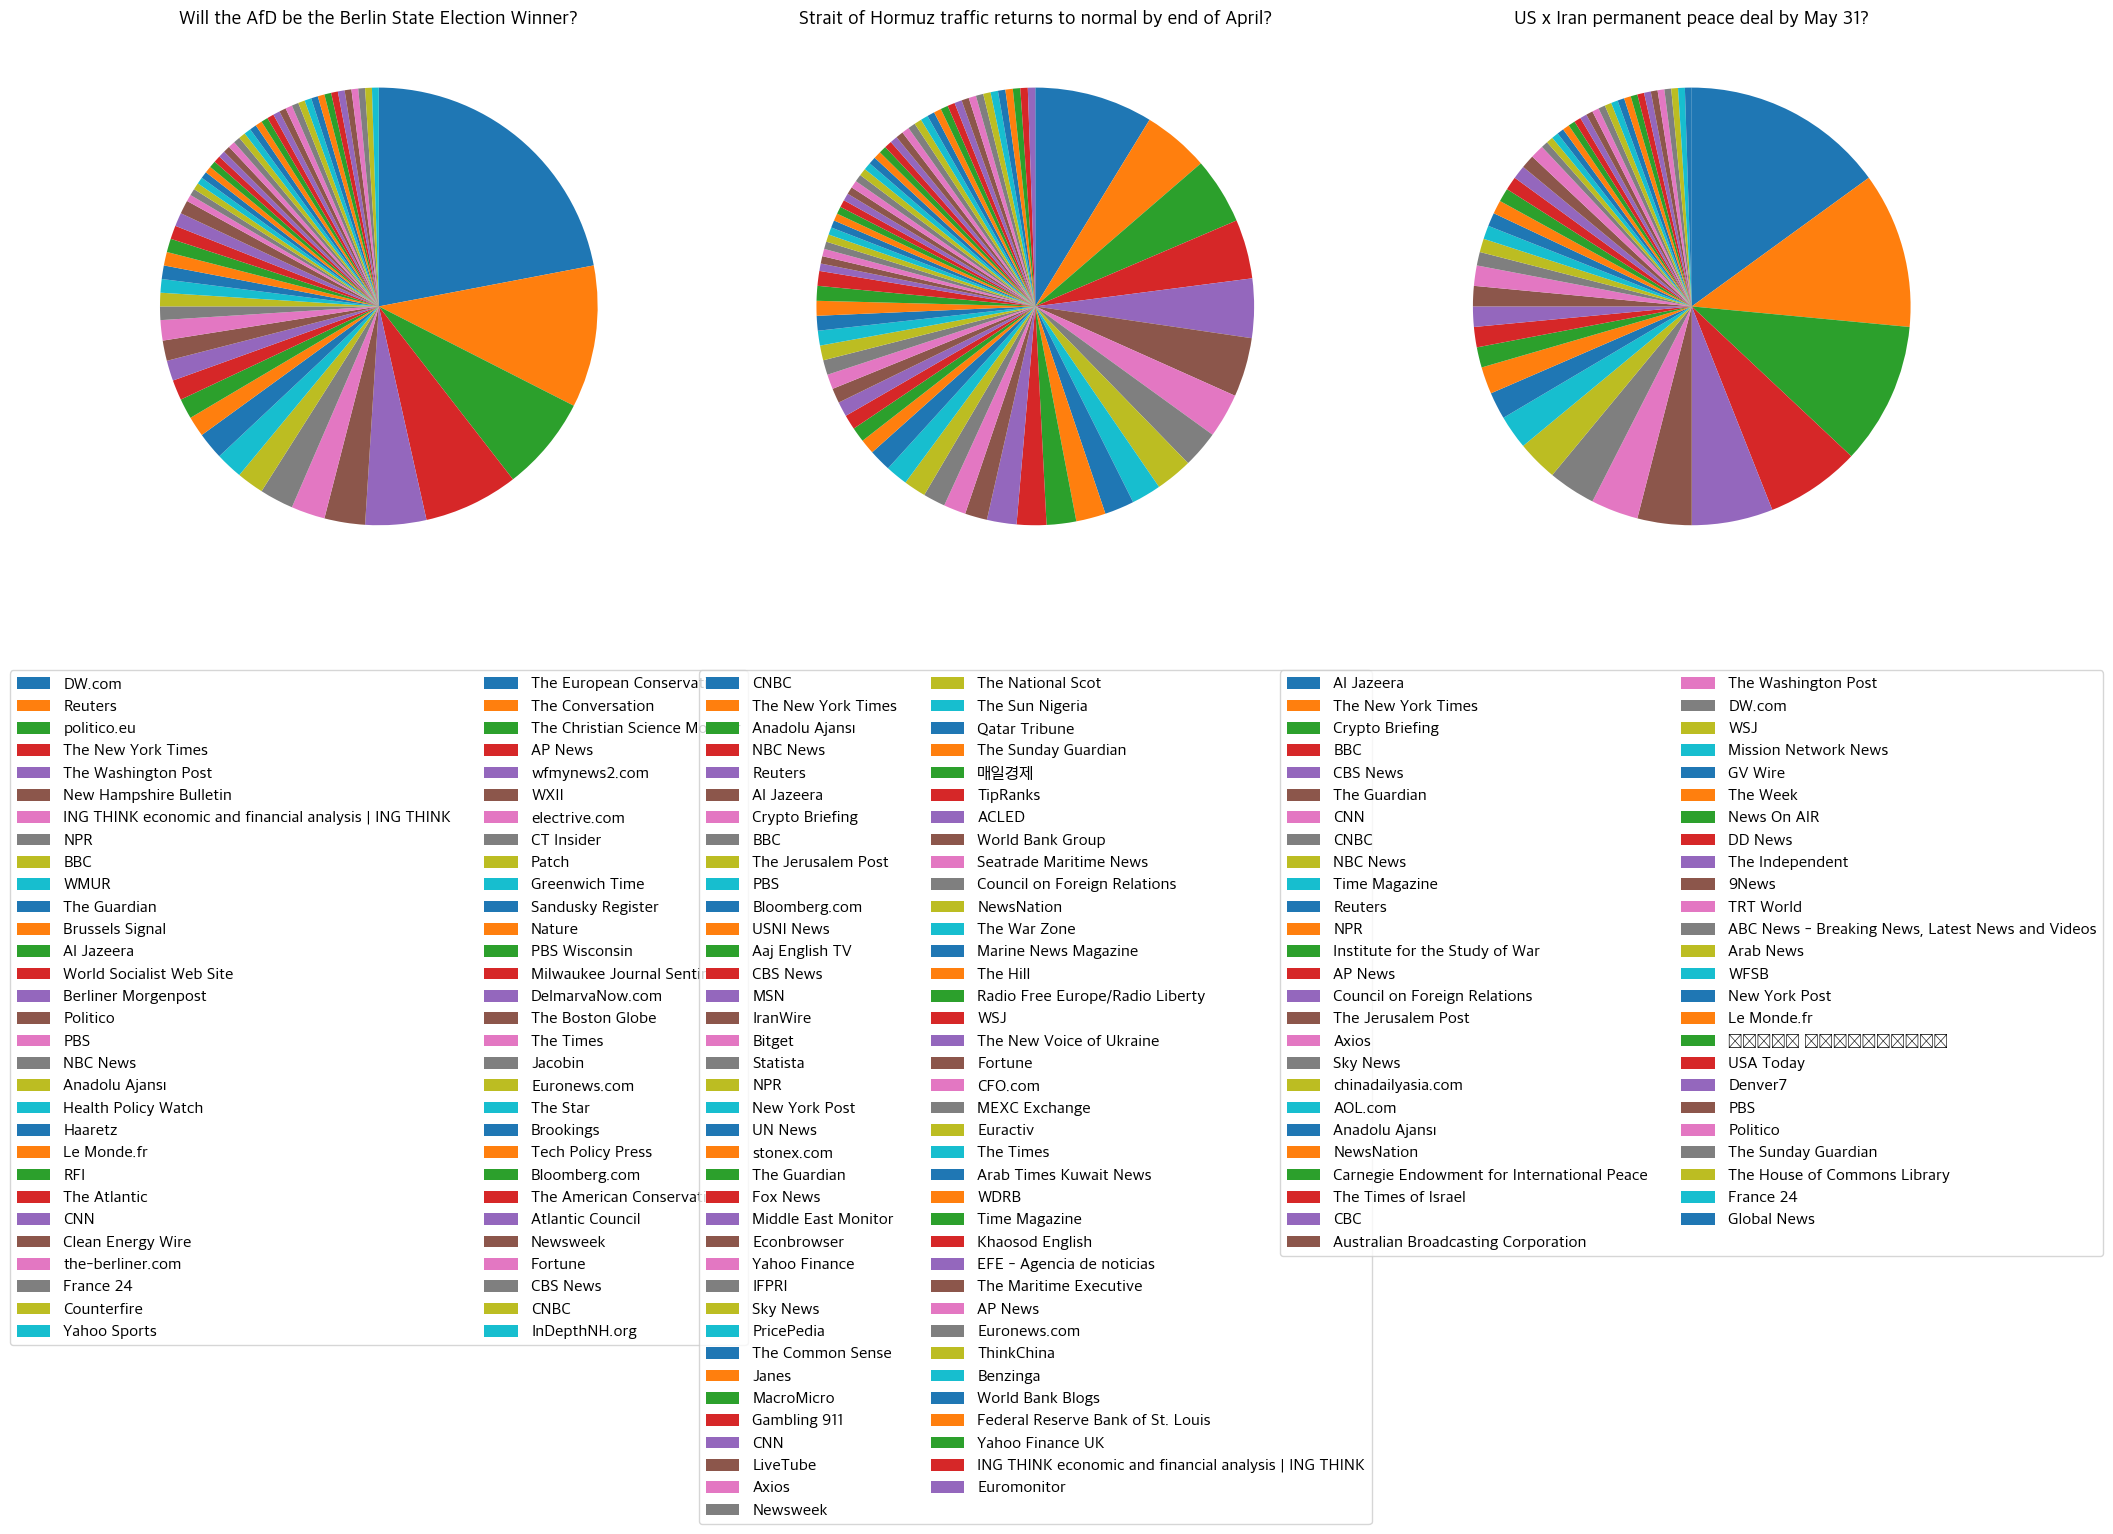



=== articles_newsapi ===
Total articles: 312
Missing full text: 7 (2.24%)
Earliest article: 30 March 2026
Latest article:   27 April 2026


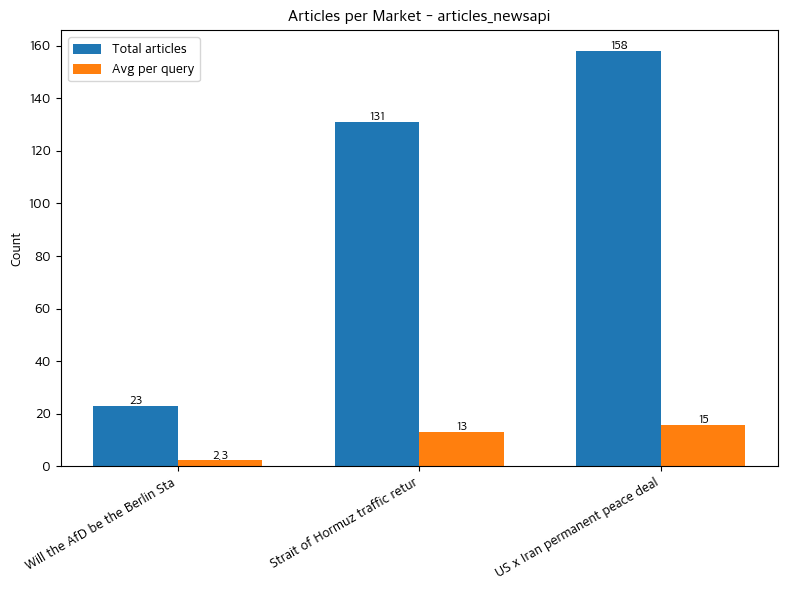

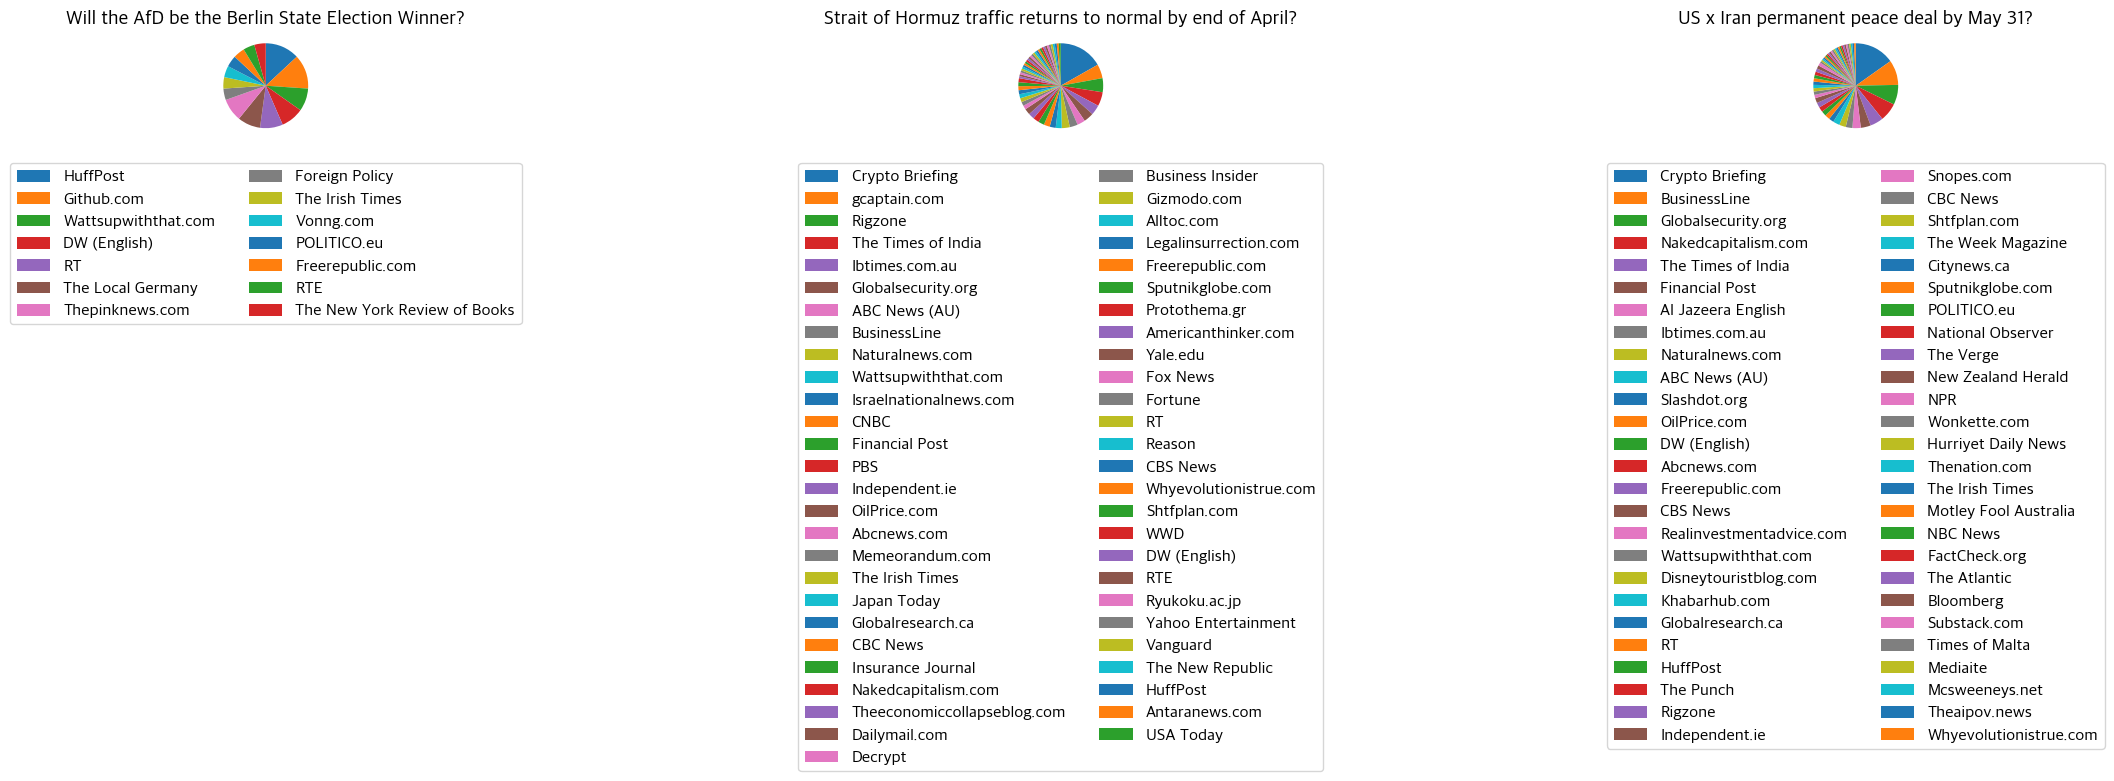

In [ ]:
import json
import glob
import os
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

COMPARISON_PATH = "data/political_markets/comparison/*_standard.json"

def parse_date(d):
    if not d:
        return None
    try:
        return datetime.fromisoformat(d.replace("Z", "+00:00"))
    except Exception:
        return None

def fmt_date(d):
    return d.strftime("%d %B %Y") if d else "N/A"

def process_dataset(data, dataset_name, date_key="published_date", source_fn=lambda a: a.get("source") or "Unknown"):
    all_articles = []
    missing_full = 0
    all_dates = []

    for market in data:
        for q in market.get("queries", []):
            articles = q.get("articles", [])  # Changed from q.get("response", {}).get("articles", [])
            
            for a in articles:
                all_articles.append(a)
                
                if not a.get("full_text"):
                    missing_full += 1
                
                d = parse_date(a.get(date_key))
                if d:
                    all_dates.append(d)
    
    total = len(all_articles)
    
    print(f"\n=== {dataset_name} ===")
    print(f"Total articles: {total}")
    
    if total:
        print(f"Missing full text: {missing_full} ({missing_full/total:.2%})")
    else:
        print(f"Missing full text: {missing_full} (0%)")
    
    if all_dates:
        print(f"Earliest article: {fmt_date(min(all_dates))}")
        print(f"Latest article:   {fmt_date(max(all_dates))}")
    else:
        print("No valid dates found")
    
    if total == 0:
        print("No articles to plot")
        return
    
    # =========================
    # BAR PLOT
    # =========================
    market_names = []
    total_articles = []
    avg_per_query = []
    
    for market in data:
        name = market.get("question", "")[:30]
        
        queries = market.get("queries", [])
        n_queries = len(queries)
        
        count = 0
        for q in queries:
            articles = q.get("articles", [])  # Changed from q.get("response", {}).get("articles", [])
            count += len(articles)
        
        market_names.append(name)
        total_articles.append(count)
        avg_per_query.append(count / n_queries if n_queries else 0)
    
    x = np.arange(len(market_names))
    width = 0.35
    
    plt.figure(figsize=(8, 6))
    
    b1 = plt.bar(x - width/2, total_articles, width, label="Total articles")
    b2 = plt.bar(x + width/2, avg_per_query, width, label="Avg per query")
    
    def add_labels(bars):
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                plt.text(
                    bar.get_x() + bar.get_width()/2,
                    h,
                    f"{h:.1f}" if h < 10 else f"{int(h)}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )
    
    add_labels(b1)
    add_labels(b2)
    
    plt.xticks(x, market_names, rotation=30, ha="right")
    plt.ylabel("Count")
    plt.title(f"Articles per Market - {dataset_name}")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # =========================
    # PIE CHARTS
    # =========================
    n = len(data)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 8))
    
    if n == 1:
        axes = [axes]
    
    for ax, market in zip(axes, data):
        source_counts = defaultdict(int)
        
        for q in market.get("queries", []):
            articles = q.get("articles", [])  # Changed from q.get("response", {}).get("articles", [])
            for a in articles:
                src = source_fn(a)
                source_counts[src] += 1
        
        sorted_items = sorted(source_counts.items(), key=lambda x: x[1], reverse=True)
        
        labels = [k for k, _ in sorted_items]
        values = [v for _, v in sorted_items]
        
        if values:
            wedges, _ = ax.pie(
                values,
                startangle=90,
                counterclock=False,
                radius=1
            )
            
            ax.set_title(market.get("question", ""), fontsize=14)
            
            ax.legend(
                wedges,
                labels,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.15),
                fontsize=12,
                ncol=2
            )
        else:
            ax.set_title("No data")
    
    plt.tight_layout()
    plt.show()

# Process each file in the comparison folder
comparison_files = sorted(glob.glob(COMPARISON_PATH))

print(f"Found {len(comparison_files)} file(s) to process\n")

for file_path in comparison_files:
    # Extract filename without extension for display
    file_display_name = os.path.basename(file_path).replace("_standard.json", "")
    
    print("\n" + "="*60)
    
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    process_dataset(
        data,
        dataset_name=file_display_name,
        date_key="published_date",
        source_fn=lambda a: a.get("source") or "Unknown"
    )

### Sources overlap

GNews API: 37 unique sources
GNews Package: 139 unique sources
NewsAPI: 86 unique sources

SOURCE OVERLAP STATISTICS

Only in GNews API: 35 sources
Only in GNews Package: 129 sources
Only in NewsAPI: 75 sources

In GNews API & GNews Package only: 0 sources
In GNews API & NewsAPI only: 1 sources
In GNews Package & NewsAPI only: 9 sources

In all three: 1 sources

------------------------------------------------------------
SAMPLE SOURCES:
------------------------------------------------------------

Only in GNews API (first 5): ['The Tribune', 'Outlook India', 'Malayala Manorama', 'Devdiscourse', 'SBS Australia']

Only in GNews Package (first 5): ['CFO.com', 'Arab News', 'ING THINK economic and financial analysis | ING THINK', 'Sandusky Register', 'Arab Times Kuwait News']

Only in NewsAPI (first 5): ['Al Jazeera English', 'Mediaite', 'Financial Post', 'Business Insider', 'Realinvestmentadvice.com']

In all three (first 10): ['CNBC']


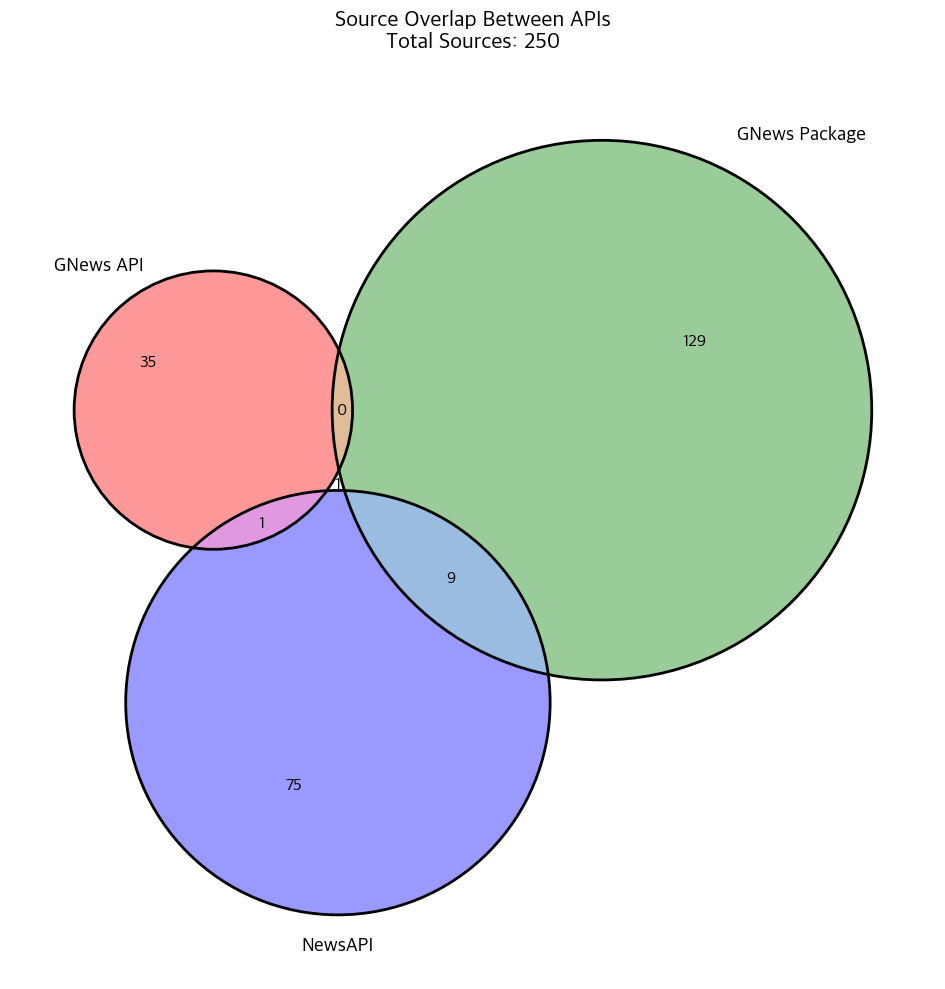


DETAILED BREAKDOWN

📰 SOURCES FOUND IN ALL THREE APIS:
  1. CNBC

📰 SOURCES FOUND IN EXACTLY TWO APIS:
  • Bloomberg (GNews API & NewsAPI)
  • CBS News (GNews Package & NewsAPI)
  • Crypto Briefing (GNews Package & NewsAPI)
  • Fortune (GNews Package & NewsAPI)
  • Fox News (GNews Package & NewsAPI)
  • NBC News (GNews Package & NewsAPI)
  • NPR (GNews Package & NewsAPI)
  • PBS (GNews Package & NewsAPI)
  • The Atlantic (GNews Package & NewsAPI)
  • USA Today (GNews Package & NewsAPI)

📰 UNIQUE TO GNews API (first 10):
  • ABC17News.com
  • Africanews
  • Al-Monitor
  • Barchart
  • Business Today
  • CoinGape
  • Crypto News
  • Daily Excelsior
  • Devdiscourse
  • Hindustan Times
  ... and 25 more

📰 UNIQUE TO GNews Package (first 10):
  • 9News
  • ABC News - Breaking News, Latest News and Videos
  • ACLED
  • AOL.com
  • AP News
  • Aaj English TV
  • Al Jazeera
  • Anadolu Ajansı
  • Arab News
  • Arab Times Kuwait News
  ... and 119 more

📰 UNIQUE TO NewsAPI (first 10):
  • ABC

In [ ]:
import json
import glob
import os
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt

# Path to your comparison folder
COMPARISON_PATH = "data/political_markets/comparison/*_standard.json"

# Load all datasets
datasets = {}
for file_path in sorted(glob.glob(COMPARISON_PATH)):
    base_name = os.path.basename(file_path).replace("_standard.json", "")
    # Clean up names for display
    if 'newsapi' in base_name.lower():
        display_name = 'NewsAPI'
    elif 'gnews_api' in base_name.lower():
        display_name = 'GNews API'
    elif 'gnews_package' in base_name.lower():
        display_name = 'GNews Package'
    else:
        display_name = base_name
    
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extract unique sources from this dataset
    sources = set()
    for market in data:
        for query in market.get('queries', []):
            for article in query.get('articles', []):
                source = article.get('source')
                if source and source != "Unknown":
                    # Normalize source names (lowercase, strip whitespace)
                    source_clean = source.strip()
                    if source_clean:
                        sources.add(source_clean)
    
    datasets[display_name] = sources
    print(f"{display_name}: {len(sources)} unique sources")

# Get sources for each dataset
if len(datasets) == 3:
    names = list(datasets.keys())
    set1 = datasets[names[0]]
    set2 = datasets[names[1]]
    set3 = datasets[names[2]]
    
    # Calculate overlaps
    only_1 = set1 - set2 - set3
    only_2 = set2 - set1 - set3
    only_3 = set3 - set1 - set2
    
    only_1_2 = (set1 & set2) - set3
    only_1_3 = (set1 & set3) - set2
    only_2_3 = (set2 & set3) - set1
    
    all_three = set1 & set2 & set3
    
    # Print statistics
    print("\n" + "="*60)
    print("SOURCE OVERLAP STATISTICS")
    print("="*60)
    print(f"\nOnly in {names[0]}: {len(only_1)} sources")
    print(f"Only in {names[1]}: {len(only_2)} sources")
    print(f"Only in {names[2]}: {len(only_3)} sources")
    print(f"\nIn {names[0]} & {names[1]} only: {len(only_1_2)} sources")
    print(f"In {names[0]} & {names[2]} only: {len(only_1_3)} sources")
    print(f"In {names[1]} & {names[2]} only: {len(only_2_3)} sources")
    print(f"\nIn all three: {len(all_three)} sources")
    
    # Print sample sources from each region
    print("\n" + "-"*60)
    print("SAMPLE SOURCES:")
    print("-"*60)
    
    if only_1:
        print(f"\nOnly in {names[0]} (first 5): {list(only_1)[:5]}")
    if only_2:
        print(f"\nOnly in {names[1]} (first 5): {list(only_2)[:5]}")
    if only_3:
        print(f"\nOnly in {names[2]} (first 5): {list(only_3)[:5]}")
    
    if all_three:
        print(f"\nIn all three (first 10): {list(all_three)[:10]}")
    
    # Create Venn diagram
    plt.figure(figsize=(12, 10))
    
    # Create the Venn diagram
    venn = venn3(
        subsets=(len(only_1), len(only_2), len(only_1_2), 
                 len(only_3), len(only_1_3), len(only_2_3), 
                 len(all_three)),
        set_labels=(names[0], names[1], names[2])
    )
    
    # Customize appearance
    for text in venn.set_labels:
        text.set_fontsize(14)
        text.set_fontweight('bold')
    
    for text in venn.subset_labels:
        if text:
            text.set_fontsize(12)
            text.set_fontweight('bold')
    
    # Add circles outline
    c = venn3_circles(
        subsets=(len(only_1), len(only_2), len(only_1_2), 
                 len(only_3), len(only_1_3), len(only_2_3), 
                 len(all_three)),
        linestyle='solid',
        linewidth=2
    )
    
    plt.title(f"Source Overlap Between APIs\nTotal Sources: {len(set1 | set2 | set3)}", 
              fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Create a detailed breakdown
    print("\n" + "="*60)
    print("DETAILED BREAKDOWN")
    print("="*60)
    
    # Show which sources are common to all three
    if all_three:
        print("\n📰 SOURCES FOUND IN ALL THREE APIS:")
        for i, source in enumerate(sorted(all_three), 1):
            print(f"  {i}. {source}")
    
    # Show which sources are in exactly two APIs
    print("\n📰 SOURCES FOUND IN EXACTLY TWO APIS:")
    two_way_overlaps = []
    if only_1_2:
        two_way_overlaps.extend([(source, f"{names[0]} & {names[1]}") for source in only_1_2])
    if only_1_3:
        two_way_overlaps.extend([(source, f"{names[0]} & {names[2]}") for source in only_1_3])
    if only_2_3:
        two_way_overlaps.extend([(source, f"{names[1]} & {names[2]}") for source in only_2_3])
    
    if two_way_overlaps:
        for source, pair in sorted(two_way_overlaps)[:20]:  # Show first 20
            print(f"  • {source} ({pair})")
        if len(two_way_overlaps) > 20:
            print(f"  ... and {len(two_way_overlaps) - 20} more")
    else:
        print("  None")
    
    # Show unique sources for each API
    print(f"\n📰 UNIQUE TO {names[0]} (first 10):")
    for source in sorted(only_1)[:10]:
        print(f"  • {source}")
    if len(only_1) > 10:
        print(f"  ... and {len(only_1) - 10} more")
    
    print(f"\n📰 UNIQUE TO {names[1]} (first 10):")
    for source in sorted(only_2)[:10]:
        print(f"  • {source}")
    if len(only_2) > 10:
        print(f"  ... and {len(only_2) - 10} more")
    
    print(f"\n📰 UNIQUE TO {names[2]} (first 10):")
    for source in sorted(only_3)[:10]:
        print(f"  • {source}")
    if len(only_3) > 10:
        print(f"  ... and {len(only_3) - 10} more")

else:
    print(f"Expected 3 datasets, but found {len(datasets)}. Check your comparison folder.")
    for name, sources in datasets.items():
        print(f"  - {name}: {len(sources)} sources")